In [1]:
import argparse
from pathlib import Path

import numpy as np
from scipy.stats import pearsonr
from statsmodels.stats.multitest import multipletests

import pandas as pd
import scanpy as sc

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
# ---------------------------------------------------------------------------
# TPS computation
# ---------------------------------------------------------------------------

def compute_tps_matrix(adata, df_de, celltype_col="derived_class2_Dec2024",
                       donor_col="participant_id", de_celltype_col="cell_type",  de_gene_col="geneID",
                       de_logfc_col="logFC", cell_types=None,  min_cells_per_donor=0):
    
    """
    Compute TPS for each (cell type, donor) pair.

    Parameters
    ----------
    adata : anndata.AnnData
        Single-nucleus RNA-seq data with obs containing celltype_col and donor_col.
    df_de : pandas.DataFrame
        DE results with columns [de_celltype_col, de_gene_col, de_logfc_col].
    celltype_col : str
        Column in adata.obs with cell type labels.
    donor_col : str
        Column in adata.obs with donor / participant ID.
    de_celltype_col : str
        Column in df_de with cell type labels (matching celltype_col).
    de_gene_col : str
        Column with gene IDs (matching adata.var_names).
    de_logfc_col : str
        Column with log fold change values.
    cell_types : list or None
        List of cell types to process. If None, uses intersection of
        cell types present in adata and df_de.
    min_cells_per_donor : int
        If > 0, require at least this many nuclei per (cell type, donor)
        to include that cell type in TPS computation.

    Returns
    -------
    TPS_matrix : pandas.DataFrame
        DataFrame with index = cell types, columns = donors, values = TPS.
    """
    # Determine cell types to use
    adata_celltypes = adata.obs[celltype_col].unique()
    de_celltypes = df_de[de_celltype_col].unique()

    if cell_types is None:
        cell_types = sorted(set(adata_celltypes).intersection(de_celltypes))

    donors = adata.obs[donor_col].unique()
    TPS_matrix = pd.DataFrame(index=cell_types, columns=donors, dtype=float)

    # Optional: filter cell types by minimum cell count per donor
    if min_cells_per_donor > 0:
        counts = (
            adata.obs.groupby([celltype_col, donor_col])
            .size()
            .reset_index(name="n_cells")
        )
        counts_pivot = (
            counts.pivot(index=celltype_col, columns=donor_col, values="n_cells")
            .fillna(0)
        )
        keep_celltypes = counts_pivot[
            (counts_pivot >= min_cells_per_donor).all(axis=1)
        ].index
        cell_types = [ct for ct in cell_types if ct in keep_celltypes]

    print(f"Computing TPS for cell types: {cell_types}")
    print(f"Number of donors: {len(donors)}")

    # Iterate over cell types
    for cell_type in cell_types:
        print(f"  -> {cell_type}")

        # Subset AnnData to this cell type
        mask = adata.obs[celltype_col] == cell_type
        adata_sub = adata[mask]

        if adata_sub.n_obs == 0:
            print(f"    Skipping {cell_type}: no cells.")
            continue

        # Compute mean expression per gene per donor
        # to_df() returns a (cells x genes) DataFrame with var_names as columns
        expr_df = adata_sub.to_df()
        donor_series = adata_sub.obs[donor_col]
        mean_expr = expr_df.groupby(donor_series).mean()  # donors x genes

        # Subset DE to this cell type and index by gene ID
        de_sub = df_de[df_de[de_celltype_col] == cell_type].set_index(de_gene_col)

        # Restrict to genes present in both expression and DE
        common_genes = mean_expr.columns.intersection(de_sub.index)
        if len(common_genes) < 10:
            print(
                f"    Warning: {cell_type} has only {len(common_genes)} common genes, skipping."
            )
            continue

        mean_expr = mean_expr[common_genes]
        de_logfc = de_sub.loc[common_genes, de_logfc_col]

        # Baseline expression (mean across donors)
        baseline_expr = mean_expr.mean(axis=0)

        # Compute TPS per donor
        for donor in mean_expr.index:
            expr_profile = mean_expr.loc[donor]

            # Residualize by baseline expression and correlate with logFC
            try:
                r, _ = pearsonr(expr_profile - baseline_expr, de_logfc)
            except Exception:
                r = np.nan

            TPS_matrix.loc[cell_type, donor] = r

    return TPS_matrix


def compute_donor_tps(TPS_matrix, cell_types=None):
    """
    Compute donor-level TPS as mean across selected cell types.

    Parameters
    ----------
    TPS_matrix : pandas.DataFrame
        (cell types x donors) matrix of TPS values.
    cell_types : list or None
        Cell types to average over. If None, use all rows.

    Returns
    -------
    donor_TPS : pandas.Series
        Index = donors, values = mean TPS.
    """
    if cell_types is not None:
        missing = [ct for ct in cell_types if ct not in TPS_matrix.index]
        if missing:
            print(f"Warning: requested cell types not in TPS_matrix: {missing}")
        TPS_sub = TPS_matrix.loc[[ct for ct in cell_types if ct in TPS_matrix.index]]
    else:
        TPS_sub = TPS_matrix

    donor_TPS = TPS_sub.mean(axis=0)
    return donor_TPS


# ---------------------------------------------------------------------------
# Plotting
# ---------------------------------------------------------------------------

def plot_tps_heatmap(TPS_matrix, out_path=None):
    """
    Plot a simple TPS heatmap (cell types x donors).

    Parameters
    ----------
    TPS_matrix : pandas.DataFrame
    out_path : pathlib.Path
        Output file path for PNG.
    """
    # Order donors and cell types by average TPS
    ordered_donors = TPS_matrix.mean(axis=0).sort_values().index
    ordered_celltypes = TPS_matrix.mean(axis=1).sort_values().index

    plt.figure(figsize=(12, 5))
    sns.heatmap(
        TPS_matrix.loc[ordered_celltypes, ordered_donors],
        cmap="coolwarm",
        center=0,
        xticklabels=True,
        yticklabels=True,
    )
    plt.xlabel("Donor (participant_id)")
    plt.ylabel("Cell type")
    plt.title("Transcriptomic Pathology Score (TPS)")
    plt.tight_layout()
    if out_path is not None:
        plt.savefig(out_path, dpi=300)
    plt.close()
    print(f"Saved TPS heatmap to: {out_path}")


# ---------------------------------------------------------------------------
# CLI
# ---------------------------------------------------------------------------

def parse_args():
    p = argparse.ArgumentParser(
        description="Compute Transcriptomic Pathology Scores (TPS) "
        "from snRNA-seq AnnData and DE results."
    )
    p.add_argument(
        "--adata",
        required=True,
        help="Path to input .h5ad file with snRNA-seq data.",
    )
    p.add_argument(
        "--de_csv",
        required=True,
        help="Path to DE results CSV file.",
    )
    p.add_argument(
        "--outdir",
        required=True,
        help="Output directory for TPS CSVs and plots.",
    )
    p.add_argument(
        "--celltype_col",
        default="derived_class2_Dec2024",
        help="Column name in adata.obs with cell type labels.",
    )
    p.add_argument(
        "--donor_col",
        default="participant_id",
        help="Column name in adata.obs with donor IDs.",
    )
    p.add_argument(
        "--de_celltype_col",
        default="cell_type",
        help="Column name in DE table with cell type labels.",
    )
    p.add_argument(
        "--de_gene_col",
        default="geneID",
        help="Column name in DE table with gene identifiers.",
    )
    p.add_argument(
        "--de_logfc_col",
        default="logFC",
        help="Column name in DE table with log fold-change values.",
    )
    p.add_argument(
        "--min_cells_per_donor",
        type=int,
        default=0,
        help="Minimum number of cells per (cell type, donor) required "
        "to include that cell type (default: 0 = no filter).",
    )
    p.add_argument(
        "--cell_types",
        nargs="+",
        default=None,
        help="Optional explicit list of cell types to include "
        "(e.g. --cell_types Astro EN Endo IN Mural Myeloid OPC Oligo).",
    )
    p.add_argument(
        "--no_plot",
        action="store_true",
        help="If set, do not generate TPS heatmap.",
    )
    return p.parse_args()

In [3]:
## FDR Calculation Function ##

def fdr_per_celltype(dge_df):
    """Add FDR-adjusted p-values and significance per cell type."""
    dge_df['p.adjusted'] = None
    dge_df['significant_fdr'] = False
    
    for celltype, group in dge_df.groupby('assay'):
        rejected, pvals_corrected, _, _ = multipletests(group['p.value'], method='fdr_bh')
        dge_df.loc[group.index, 'p.adjusted'] = pvals_corrected
        dge_df.loc[group.index, 'significant_fdr'] = rejected
    
    return dge_df

In [4]:
## Import Dreamlet DGE ##

dreamlet_dge = pd.read_parquet('/mnt/sdb/scz_meta_analysis_processed/psychad_mapping/res_meta.parquet')

dreamlet_metadata = pd.read_excel('/mnt/sdb/scz_meta_analysis_processed/psychad_mapping/contrast_pairs.xlsx')

dreamlet_combined = pd.read_parquet('/mnt/sdb/scz_meta_analysis_processed/psychad_mapping/topTable_combined.parquet')

In [5]:
hbcc_bool = dreamlet_combined['Dataset'] == 'HBCC'
scz_bool = dreamlet_combined['coef'] == 'c08xSCZ - c08xControl'
class_bool = dreamlet_combined['AnnoLevel'] == 'class'

In [6]:
dreamlet_combined[hbcc_bool]['coef'][dreamlet_combined[hbcc_bool]['coef'].str.contains('SCZ')].unique()

array(['c48xSCZ_crossDis - c48xControls_crossDis', 'c39xSCZ - c39xBD',
       'c38xSCZ - c38xBD', 'c08xSCZ - c08xControl'], dtype=object)

In [7]:
dreamlet_combined[hbcc_bool]['coef'].unique()[0:40]

array(['c37xBD - c37xControl', 'c36xBD - c36xControl',
       'c53xBD_crossDis - c53xControls_crossDis',
       'c48xSCZ_crossDis - c48xControls_crossDis', 'c39xSCZ - c39xBD',
       'c38xSCZ - c38xBD', 'c08xSCZ - c08xControl',
       'c19xSeizures - c19xControl'], dtype=object)

In [8]:
hbcc_scz = dreamlet_combined[(hbcc_bool & scz_bool & class_bool)]

In [46]:
CSV_PATH = '/mnt/sdb/scz_meta_analysis_processed/dge_signatures/dreamlet_dges/disease_analyses/'

# by manuscript #
dge_walsh_22q11 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_walsh_22q11_dge_scz_results.csv')
dge_walsh_15q13 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_walsh_15q13_dge_scz_results.csv')
dge_nrxn1 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_nrxn1_combined.csv')
dge_22q11 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_22q11_combined.csv')
dge_idiopathic = pd.read_csv(Path(CSV_PATH) / 'dreamlet_idiopathic_combined.csv')

In [111]:
adata.obs['Ancestry'].value_counts() / adata.obs['Ancestry'].value_counts().sum()

Ancestry
Caucasian            0.737411
Non-Caucasian        0.226575
Japanese             0.013430
Unknown              0.011612
Ad-mixed American    0.010972
Name: count, dtype: float64

In [100]:
dge_idiopathic

,ID,assay,estimate,std.error,statistic,p.value,n.studies,method,psychad_celltypes
0,A1BG,Mesenchymal-like cells VIM+VCAN+SPARC+,0.355352,0.571959,0.621290,0.534409,1,FE,Mesenchymal-like cells VIM+VCAN+SPARC+
1,A1BG,Proliferative Radial Glia SOX2+HES6+TOP2A+,1.353854,0.634559,2.133534,0.032881,1,FE,Proliferative Radial Glia SOX2+HES6+TOP2A+
2,A1BG,Radial Glia SOX2+PAX6+FABP7+,0.309485,0.318147,0.972774,0.330666,1,FE,Radial Glia SOX2+PAX6+FABP7+
3,A1BG-AS1,Mesenchymal-like cells VIM+VCAN+SPARC+,-0.306088,0.332704,-0.920000,0.357573,1,FE,Mesenchymal-like cells VIM+VCAN+SPARC+
4,AAAS,Mesenchymal-like cells VIM+VCAN+SPARC+,0.109481,0.229449,0.477147,0.633257,1,FE,Mesenchymal-like cells VIM+VCAN+SPARC+
...,...,...,...,...,...,...,...,...,...
35225,ZZEF1,Mesenchymal-like cells VIM+VCAN+SPARC+,0.216788,0.181727,1.192933,0.232896,1,FE,Mesenchymal-like cells VIM+VCAN+SPARC+
35226,ZZZ3,Mesenchymal-like cells VIM+VCAN+SPARC+,-0.380565,0.176595,-2.155013,0.031161,1,FE,Mesenchymal-like cells VIM+VCAN+SPARC+
35227,ZZZ3,Proliferative Radial Glia SOX2+HES6+TOP2A+,0.090411,0.296172,0.305267,0.760163,1,FE,Proliferative Radial Glia SOX2+HES6+TOP2A+
35228,ZZZ3,Radial Glia SOX2+PAX6+FABP7+,-0.257875,0.273861,-0.941627,0.346384,1,FE,Radial Glia SOX2+PAX6+FABP7+


In [70]:
dge_idiopathic['psychad_celltypes'] = dge_idiopathic['assay'].astype('str')

dge_idiopathic.loc[dge_idiopathic['psychad_celltypes'].str.contains('Neuron'), 'psychad_celltypes'] = 'EN'
dge_idiopathic.loc[dge_idiopathic['psychad_celltypes'].str.contains('GABAergic'), 'psychad_celltypes'] = 'IN'
dge_idiopathic.loc[(dge_idiopathic['psychad_celltypes'] == 'OPC'), 'psychad_celltypes'] = 'OPC'
dge_idiopathic.loc[(dge_idiopathic['psychad_celltypes'] == 'Oligodendrocyte'), 'psychad_celltypes'] = 'Oligo'
dge_idiopathic.loc[(dge_idiopathic['psychad_celltypes'] == 'Astrocyte'), 'psychad_celltypes'] = 'Astro'

dge_22q11['psychad_celltypes'] = dge_22q11['assay'].astype('str')

dge_22q11.loc[dge_22q11['psychad_celltypes'].str.contains('Neuron'), 'psychad_celltypes'] = 'EN'
dge_22q11.loc[dge_22q11['psychad_celltypes'].str.contains('GABAergic'), 'psychad_celltypes'] = 'IN'
dge_22q11.loc[(dge_22q11['psychad_celltypes'] == 'OPC'), 'psychad_celltypes'] = 'OPC'
dge_22q11.loc[(dge_22q11['psychad_celltypes'] == 'Oligodendrocyte'), 'psychad_celltypes'] = 'Oligo'
dge_22q11.loc[(dge_22q11['psychad_celltypes'] == 'Astrocyte'), 'psychad_celltypes'] = 'Astro'

dge_nrxn1['psychad_celltypes'] = dge_nrxn1['assay'].astype('str')

dge_nrxn1.loc[dge_nrxn1['psychad_celltypes'].str.contains('Neuron'), 'psychad_celltypes'] = 'EN'
dge_nrxn1.loc[dge_nrxn1['psychad_celltypes'].str.contains('GABAergic'), 'psychad_celltypes'] = 'IN'
dge_nrxn1.loc[(dge_nrxn1['psychad_celltypes'] == 'OPC'), 'psychad_celltypes'] = 'OPC'
dge_nrxn1.loc[(dge_nrxn1['psychad_celltypes'] == 'Oligodendrocyte'), 'psychad_celltypes'] = 'Oligo'
dge_nrxn1.loc[(dge_nrxn1['psychad_celltypes'] == 'Astrocyte'), 'psychad_celltypes'] = 'Astro'

In [68]:
def correlate_dge_to_hbcc(
    dge_df,
    hbcc_df,
    dge_celltype_col="psychad_celltypes",
    hbcc_celltype_col="assay",
    dge_gene_col="ID",
    hbcc_gene_col="ID",
    dge_effect_col="estimate",
    hbcc_effect_col="logFC",
    plot=True,
):
    """
    Compare a DGE dataframe to HBCC across all overlapping cell types.

    Returns
    -------
    summary : pd.DataFrame
        Correlation statistics for each cell type.
    merged_data : dict
        Dictionary of merged gene-level dataframes keyed by cell type.
    """

    common_celltypes = sorted(
        set(dge_df[dge_celltype_col].dropna())
        & set(hbcc_df[hbcc_celltype_col].dropna())
    )

    summary = []
    merged_data = {}

    for ct in common_celltypes:

        dge = (
            dge_df.loc[
                dge_df[dge_celltype_col] == ct,
                [dge_gene_col, dge_effect_col]
            ]
            .rename(columns={dge_effect_col: "DGE_logFC"})
            .groupby(dge_gene_col, as_index=False)
            .mean()
        )

        hbcc = (
            hbcc_df.loc[
                hbcc_df[hbcc_celltype_col] == ct,
                [hbcc_gene_col, hbcc_effect_col]
            ]
            .rename(columns={
                hbcc_gene_col: dge_gene_col,
                hbcc_effect_col: "HBCC_logFC"
            })
            .groupby(dge_gene_col, as_index=False)
            .mean()
        )

        merged = dge.merge(hbcc, on=dge_gene_col, how="inner")

        merged_data[ct] = merged

        if len(merged) < 3:
            continue

        r, p = pearsonr(merged["DGE_logFC"], merged["HBCC_logFC"])

        summary.append({
            "CellType": ct,
            "N_overlap": len(merged),
            "Pearson_r": r,
            "P_value": p
        })

        if plot:
            plt.figure(figsize=(5,5))

            sns.regplot(
                data=merged,
                x="DGE_logFC",
                y="HBCC_logFC",
                scatter_kws={"alpha":0.6, "s":18},
                line_kws={"color":"red"},
            )

            plt.title(f"{ct}\nr={r:.2f}, p={p:.2e}, n={len(merged)}")
            plt.xlabel("DGE estimate")
            plt.ylabel("HBCC logFC")
            plt.tight_layout()
            plt.show()

    summary = (
        pd.DataFrame(summary)
        .sort_values("P_value")
        .reset_index(drop=True)
    )

    return summary, merged_data

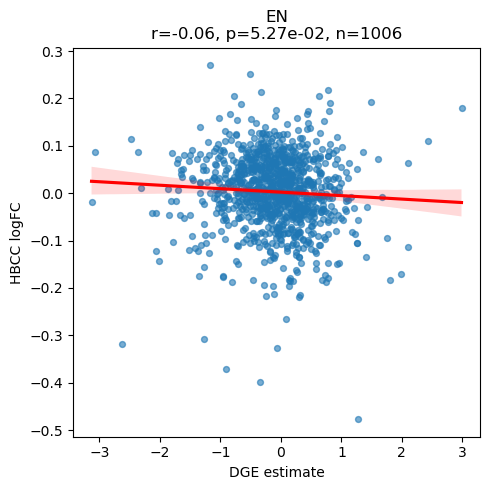

In [72]:
idiopathic_summary, idiopathic_genes = correlate_dge_to_hbcc(dge_idiopathic, hbcc_scz)

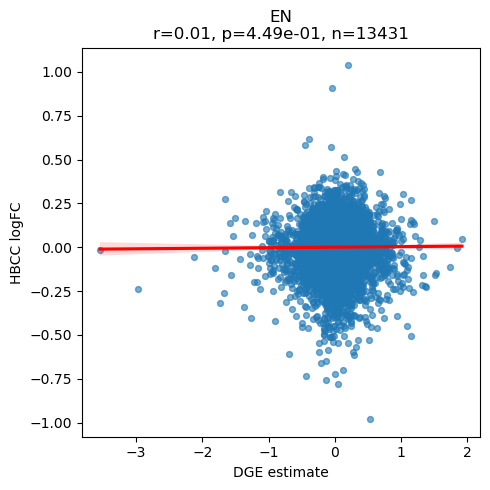

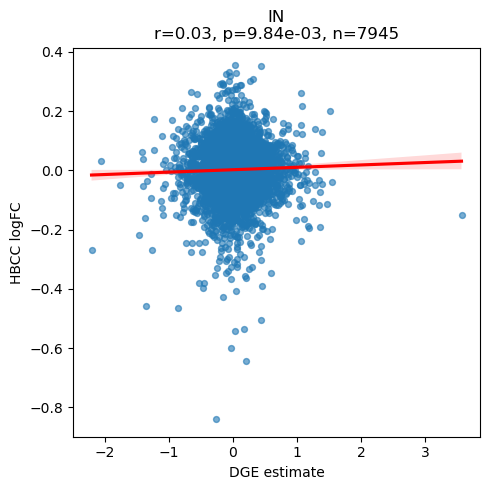

In [73]:
q22_summary, q22_genes = correlate_dge_to_hbcc(dge_22q11, hbcc_scz)

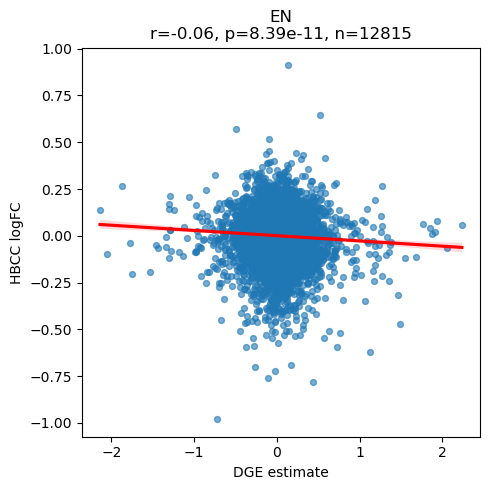

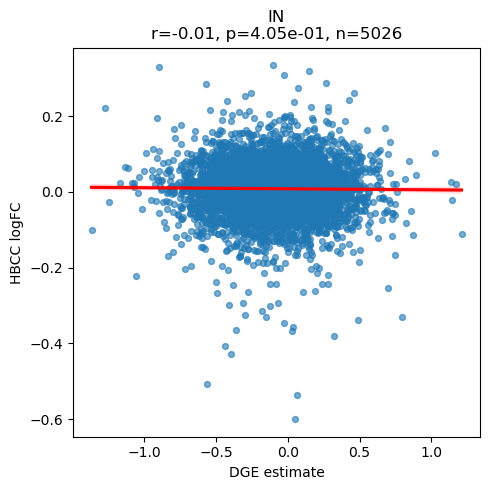

In [74]:
nrxn1_summary, nrxn1_genes = correlate_dge_to_hbcc(
    dge_nrxn1,
    hbcc_scz
)

In [9]:
## Import Scz Adata ##

adata = sc.read_h5ad('/mnt/sdb/scz_meta_analysis_processed/anndata_objs/integrated_adata_annotated_w_celltypist_scanvi.h5ad')

adata.obs['Donor_Sample'] = adata.obs['Donor'].astype('str') + '_' + adata.obs['Sample Name'].astype('str')

In [10]:
# Make PsychAD CellType Equivalents ##

adata.obs['psychad_celltypes'] = adata.obs['subclass_annotations_markers'].astype('str')

adata.obs.loc[adata.obs['subclass_annotations_markers'].str.contains('Neuron'), 'psychad_celltypes'] = 'EN'
adata.obs.loc[adata.obs['subclass_annotations_markers'].str.contains('GABAergic'), 'psychad_celltypes'] = 'IN'
adata.obs.loc[(adata.obs['subtype_cluster_annotations'] == 'OPC'), 'psychad_celltypes'] = 'OPC'
adata.obs.loc[(adata.obs['subtype_cluster_annotations'] == 'Oligodendrocyte'), 'psychad_celltypes'] = 'Oligo'
adata.obs.loc[(adata.obs['subtype_cluster_annotations'] == 'Astrocyte'), 'psychad_celltypes'] = 'Astro'

# make donor sample celltype column 
adata.obs['Donor_Sample_CellType'] = adata.obs['Donor_Sample'].astype('str') + '_' + adata.obs['psychad_celltypes'].astype('str')

adata.obs['Broad_Genotype_CellType'] = adata.obs['Donor_Sample'].astype('str') + '_' + adata.obs['psychad_celltypes'].astype('str')

In [38]:
## Check HBCC DGEs By Cell Type ##

hbcc_scz[(hbcc_scz['adj.P.Val'] < 0.05)]['assay'].value_counts()

assay
OPC       35
Endo      29
Astro     27
Mural     27
Immune    22
Oligo     21
IN        17
EN        10
Name: count, dtype: int64

In [13]:
# TPS with HBCC DGE #

# Calculate TPS #
tps_hbcc = compute_tps_matrix(adata, hbcc_scz, celltype_col="psychad_celltypes", 
                            donor_col="Donor_Sample",
                            de_celltype_col="assay", de_gene_col="ID", de_logfc_col="logFC", 
                            cell_types=None, min_cells_per_donor=0)

# Arrange TPS DF for Plotting 
tps_hbcc = tps_hbcc.T
donor_genotype_dict = dict(zip(adata.obs['Donor_Sample'], adata.obs['Broad_Genotype']))
tps_hbcc['Genotype'] = tps_hbcc.index.map(donor_genotype_dict)
tps_hbcc['Donor_Sample'] = tps_hbcc.index

tps_hbcc_melted = pd.melt(tps_hbcc, id_vars=['Genotype', 'Donor_Sample'], var_name='CellType', value_name='TPS')

Computing TPS for cell types: ['Astro', 'EN', 'IN', 'OPC', 'Oligo']
Number of donors: 100
  -> Astro
  -> EN
  -> IN
  -> OPC
  -> Oligo


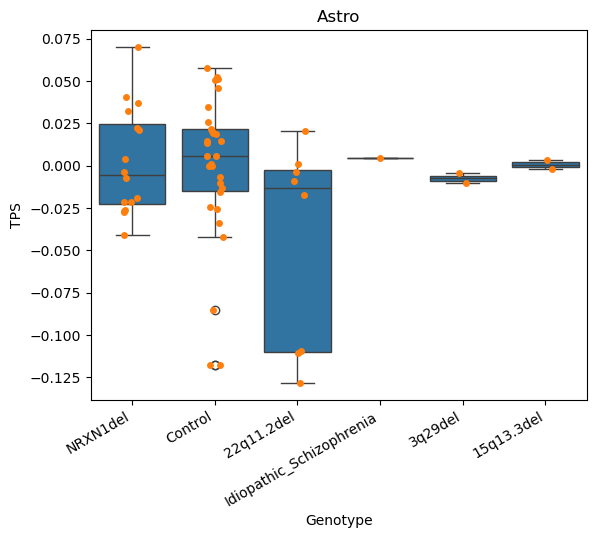

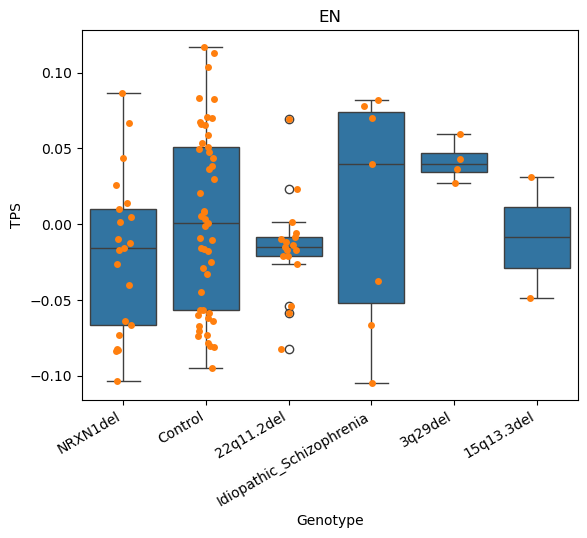

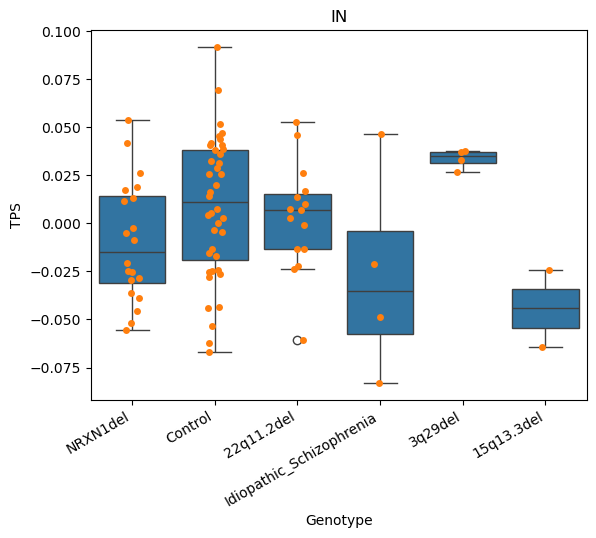

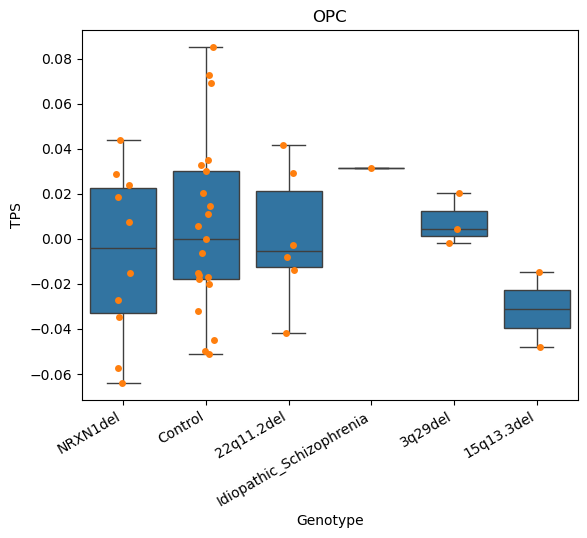

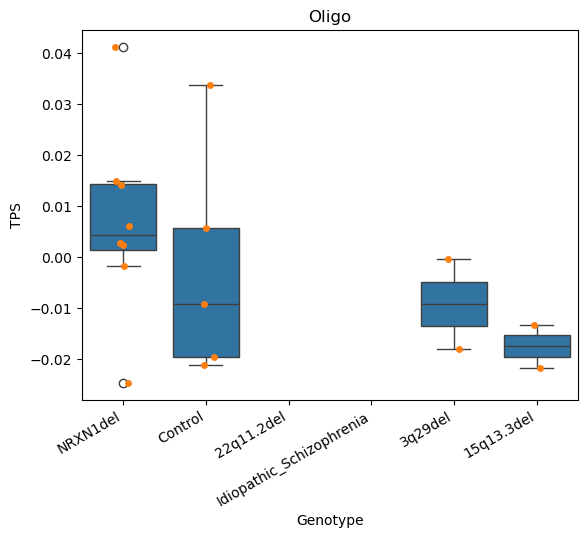

In [45]:
for celltype in tps_hbcc_melted['CellType'].unique():
    plt.title(celltype)
    sns.boxplot(tps_hbcc_melted[tps_hbcc_melted['CellType'] == celltype], x='Genotype', y='TPS')
    sns.stripplot(tps_hbcc_melted[tps_hbcc_melted['CellType'] == celltype], x='Genotype', y='TPS')
    plt.xticks(rotation=30, ha='right')
    plt.show()

In [80]:
dge_idiopathic

,ID,assay,estimate,std.error,statistic,p.value,n.studies,method,psychad_celltypes
0,A1BG,Mesenchymal-like cells VIM+VCAN+SPARC+,0.355352,0.571959,0.621290,0.534409,1,FE,Mesenchymal-like cells VIM+VCAN+SPARC+
1,A1BG,Proliferative Radial Glia SOX2+HES6+TOP2A+,1.353854,0.634559,2.133534,0.032881,1,FE,Proliferative Radial Glia SOX2+HES6+TOP2A+
2,A1BG,Radial Glia SOX2+PAX6+FABP7+,0.309485,0.318147,0.972774,0.330666,1,FE,Radial Glia SOX2+PAX6+FABP7+
3,A1BG-AS1,Mesenchymal-like cells VIM+VCAN+SPARC+,-0.306088,0.332704,-0.920000,0.357573,1,FE,Mesenchymal-like cells VIM+VCAN+SPARC+
4,AAAS,Mesenchymal-like cells VIM+VCAN+SPARC+,0.109481,0.229449,0.477147,0.633257,1,FE,Mesenchymal-like cells VIM+VCAN+SPARC+
...,...,...,...,...,...,...,...,...,...
35225,ZZEF1,Mesenchymal-like cells VIM+VCAN+SPARC+,0.216788,0.181727,1.192933,0.232896,1,FE,Mesenchymal-like cells VIM+VCAN+SPARC+
35226,ZZZ3,Mesenchymal-like cells VIM+VCAN+SPARC+,-0.380565,0.176595,-2.155013,0.031161,1,FE,Mesenchymal-like cells VIM+VCAN+SPARC+
35227,ZZZ3,Proliferative Radial Glia SOX2+HES6+TOP2A+,0.090411,0.296172,0.305267,0.760163,1,FE,Proliferative Radial Glia SOX2+HES6+TOP2A+
35228,ZZZ3,Radial Glia SOX2+PAX6+FABP7+,-0.257875,0.273861,-0.941627,0.346384,1,FE,Radial Glia SOX2+PAX6+FABP7+


In [82]:
# Let Idiopathic Be the Reference ##
tps_idio_orgaonid_ref = compute_tps_matrix(adata, dge_idiopathic, celltype_col="CellType", 
                            donor_col="Donor_Sample",
                            de_celltype_col="assay", de_gene_col="ID", de_logfc_col="estimate", 
                            cell_types=None, min_cells_per_donor=0)

Computing TPS for cell types: ['Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+', 'Hindbrain Neurons NR2F2+PBX3+LHX1+', 'Mesenchymal-like cells VIM+VCAN+SPARC+', 'Mixed Neurons FGF12+GRIN2B+CAMK2B+', 'Proliferative Radial Glia SOX2+HES6+TOP2A+', 'Radial Glia SOX2+PAX6+FABP7+', 'Radial Glia SOX2+VIM+FABP7+']
Number of donors: 100
  -> Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+
  -> Hindbrain Neurons NR2F2+PBX3+LHX1+
  -> Mesenchymal-like cells VIM+VCAN+SPARC+
  -> Mixed Neurons FGF12+GRIN2B+CAMK2B+
  -> Proliferative Radial Glia SOX2+HES6+TOP2A+
  -> Radial Glia SOX2+PAX6+FABP7+
  -> Radial Glia SOX2+VIM+FABP7+


In [85]:
# Arrange TPS DF for Plotting Where Idio SCZ Organoids are Reference ##
tps_idio_orgaonid_ref = tps_idio_orgaonid_ref.T
tps_idio_orgaonid_ref['Genotype'] = tps_idio_orgaonid_ref.index.map(donor_genotype_dict)
tps_idio_orgaonid_ref['Donor_Sample'] = tps_idio_orgaonid_ref.index

tps_idio_orgaonid_ref_melted = pd.melt(tps_idio_orgaonid_ref, id_vars=['Genotype', 'Donor_Sample'], var_name='CellType', value_name='TPS')

In [88]:
tps_idio_orgaonid_ref_melted

,Genotype,Donor_Sample,CellType,TPS
0,NRXN1del,973_GSM8779938,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,0.140973
1,NRXN1del,581_GSM8779933,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,0.034815
2,NRXN1del,581_GSM8779932,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,0.148177
3,NRXN1del,972_GSM8779937,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,-0.223016
4,Control,2607_GSM8779930,Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+,0.164508
...,...,...,...,...
695,NRXN1del,N1884a_GSM7118665,Radial Glia SOX2+VIM+FABP7+,-0.047258
696,Control,C8905a_GSM7118663,Radial Glia SOX2+VIM+FABP7+,0.139036
697,Control,H1_GSM7118675,Radial Glia SOX2+VIM+FABP7+,-0.191485
698,Control,C3141a_GSM7118654,Radial Glia SOX2+VIM+FABP7+,-0.042209


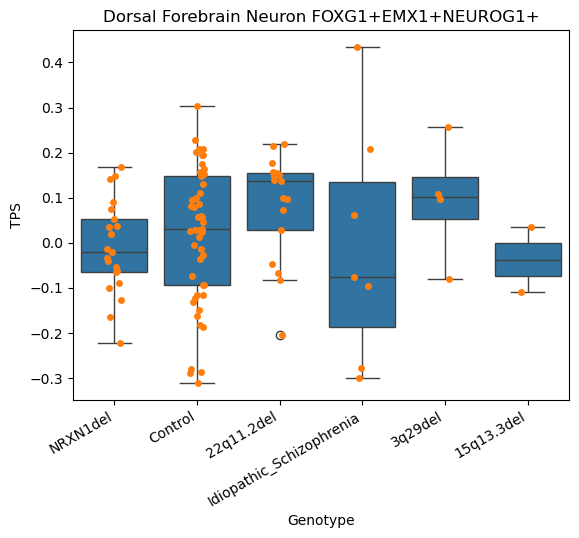

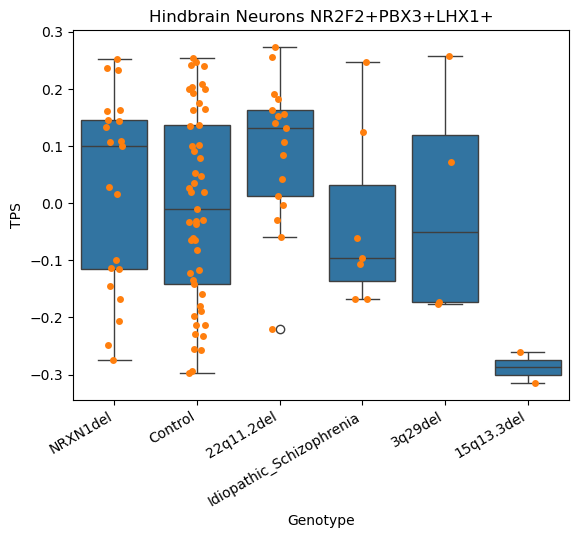

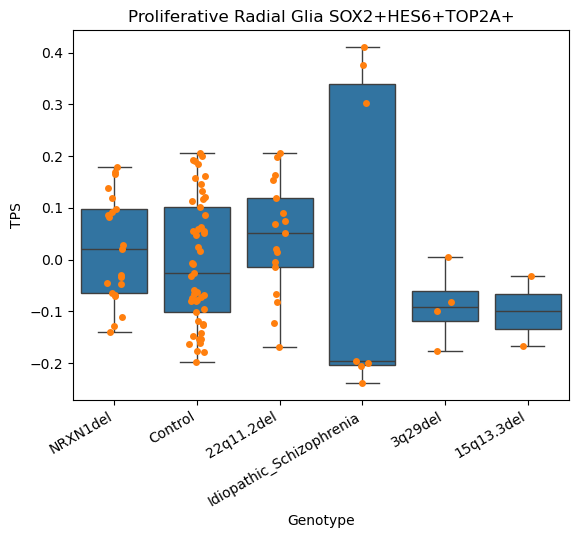

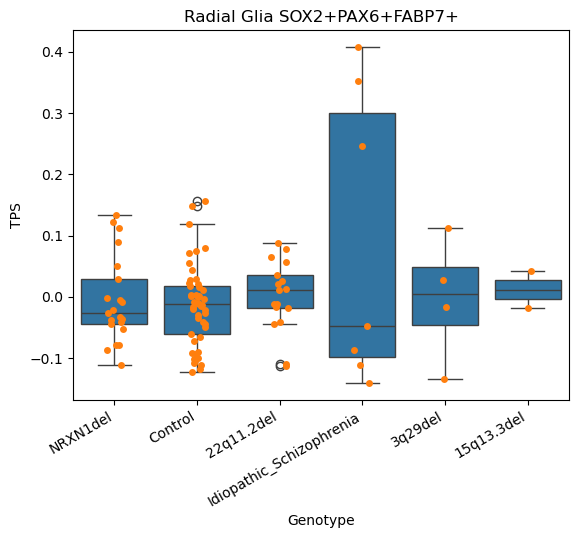

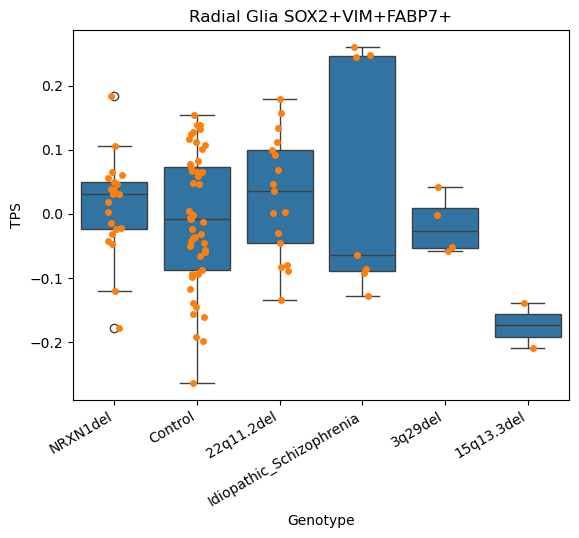

In [99]:
for celltype in tps_idio_orgaonid_ref_melted['CellType'].unique():

    if tps_idio_orgaonid_ref_melted[tps_idio_orgaonid_ref_melted['CellType'] == celltype]['TPS'].isnull().any():
        continue
    
    plt.title(celltype)
    sns.boxplot(tps_idio_orgaonid_ref_melted[tps_idio_orgaonid_ref_melted['CellType'] == celltype], x='Genotype', y='TPS')
    sns.stripplot(tps_idio_orgaonid_ref_melted[tps_idio_orgaonid_ref_melted['CellType'] == celltype], x='Genotype', y='TPS')
    plt.xticks(rotation=30, ha='right')
    plt.show()

## Note: Even Idiopathic SCZ exhibits weak TPS Scores... despite it being the reference here #

In [8]:
## Prep Dreamlet DE DF - All Cohorts and All Diseases from PsychAD ##

disease_list = ['AD', 'SCZ', 'DLBD', 'Vascular', 'Tauopathy', 'PD']
dx_code_list = ['m10x', 'm11x', 'm12x', 'm13x', 'm14x', 'm15x']

method_bool = (dreamlet_dge['method'] == 'FE') 
anno_bool = (dreamlet_dge['AnnoLevel'] == 'class')

tps_list = []

for disease, dx_code in zip(disease_list, dx_code_list):

    fe_class_dedf = None

    dx_bool = (dreamlet_dge['coef'] == dx_code)

    fe_class_dedf = dreamlet_dge[method_bool & anno_bool & dx_bool].copy()

    fe_class_dedf = fdr_per_celltype(fe_class_dedf)

    tps_dx = compute_tps_matrix(adata, fe_class_dedf, celltype_col="psychad_celltypes", 
                   donor_col="Donor_Sample",
                   de_celltype_col="assay", de_gene_col="ID", de_logfc_col="estimate", 
                   cell_types=None, min_cells_per_donor=0)

    tps_dx = tps_dx.T
    
    tps_dx.columns = [i+f'_{disease}' for i in tps_dx.columns]

    tps_list.append(tps_dx)

all_tps = pd.concat(tps_list, axis=1)

Computing TPS for cell types: ['Astro', 'EN', 'IN', 'OPC', 'Oligo']
Number of donors: 100
  -> Astro
  -> EN



KeyboardInterrupt



In [10]:
all_tps['Broad_Genotype'] = all_tps.index.map(donor_genotype_dict)

In [11]:
tps_melted = pd.melt(all_tps, id_vars=['Broad_Genotype'], var_name='CellType_Disease', value_name='TPS')

In [12]:
tps_melted['CellType'] = tps_melted['CellType_Disease'].str.split('_').apply(lambda x: x[0])
tps_melted['Disease'] = tps_melted['CellType_Disease'].str.split('_').apply(lambda x: x[1])

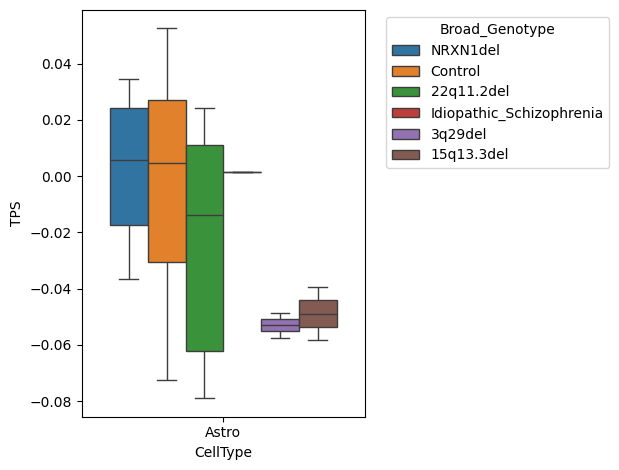

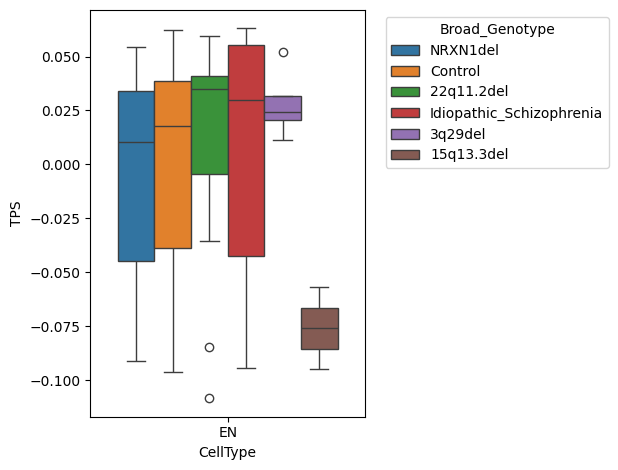

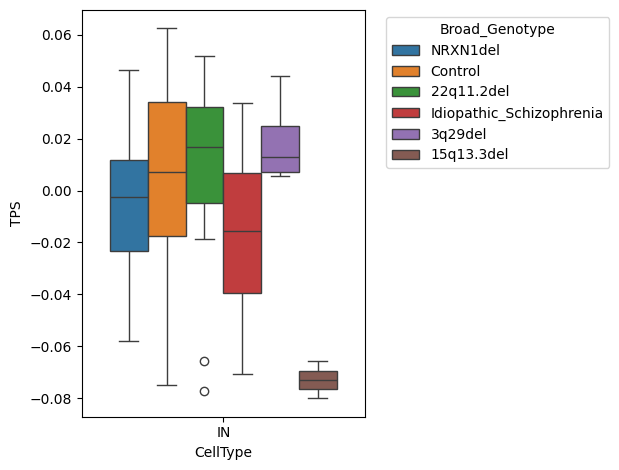

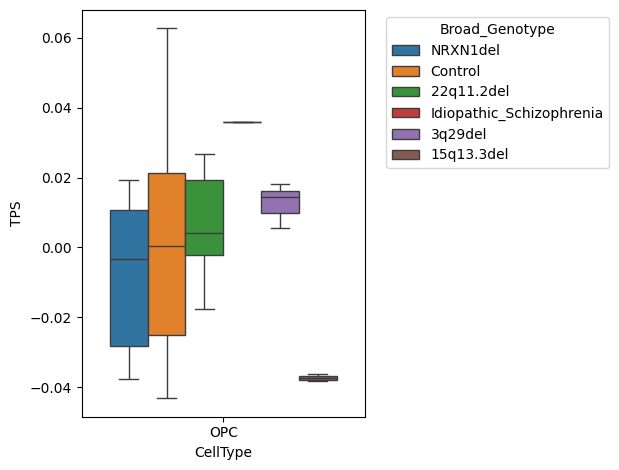

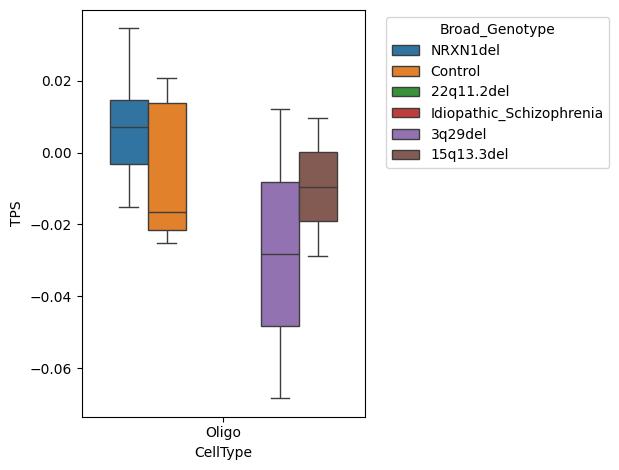

In [13]:
for celltype in tps_melted['CellType'].unique():
    temp_tps = tps_melted[
        (tps_melted['CellType'] == celltype) &
        (tps_melted['Disease'] == 'SCZ')
    ]
    
    ax = sns.boxplot(temp_tps, x='CellType', y='TPS', hue='Broad_Genotype')
    
    # Move legend to the right
    ax.legend(title='Broad_Genotype', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()  # prevents clipping
    plt.show()

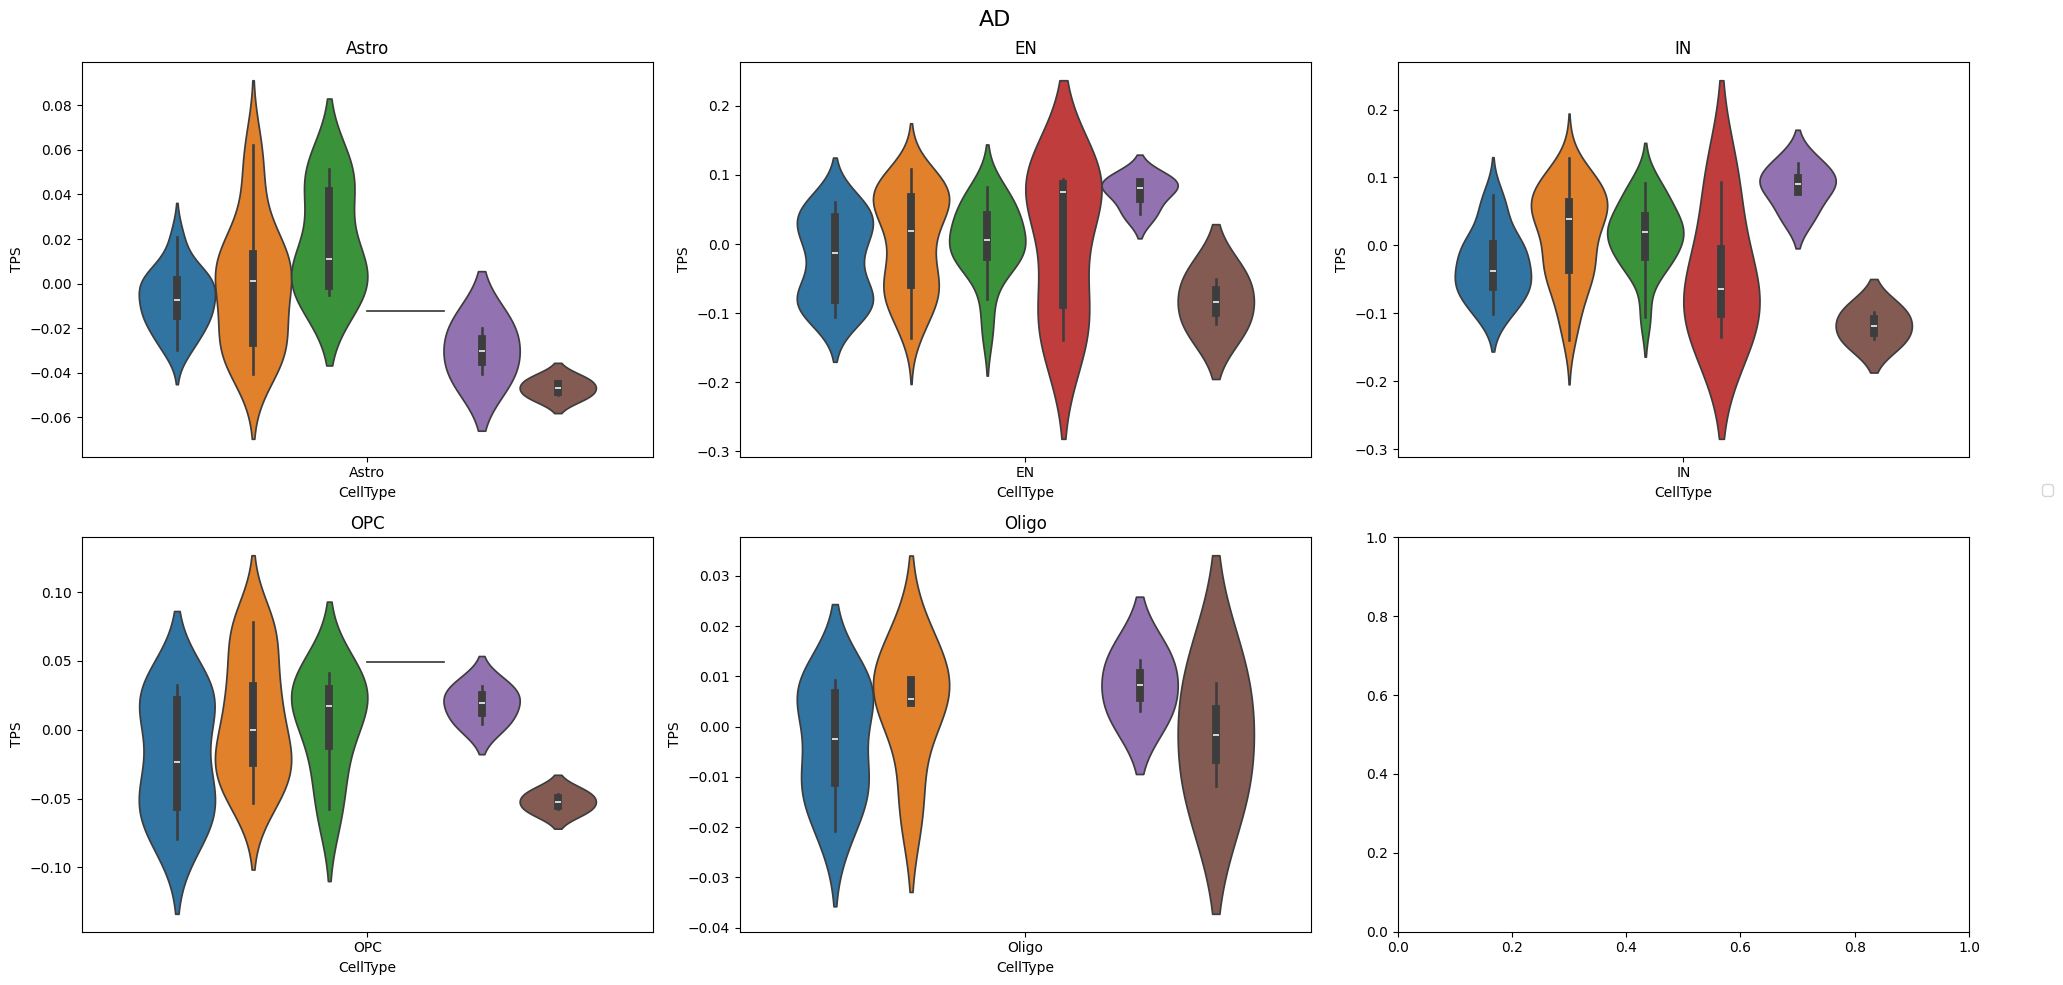

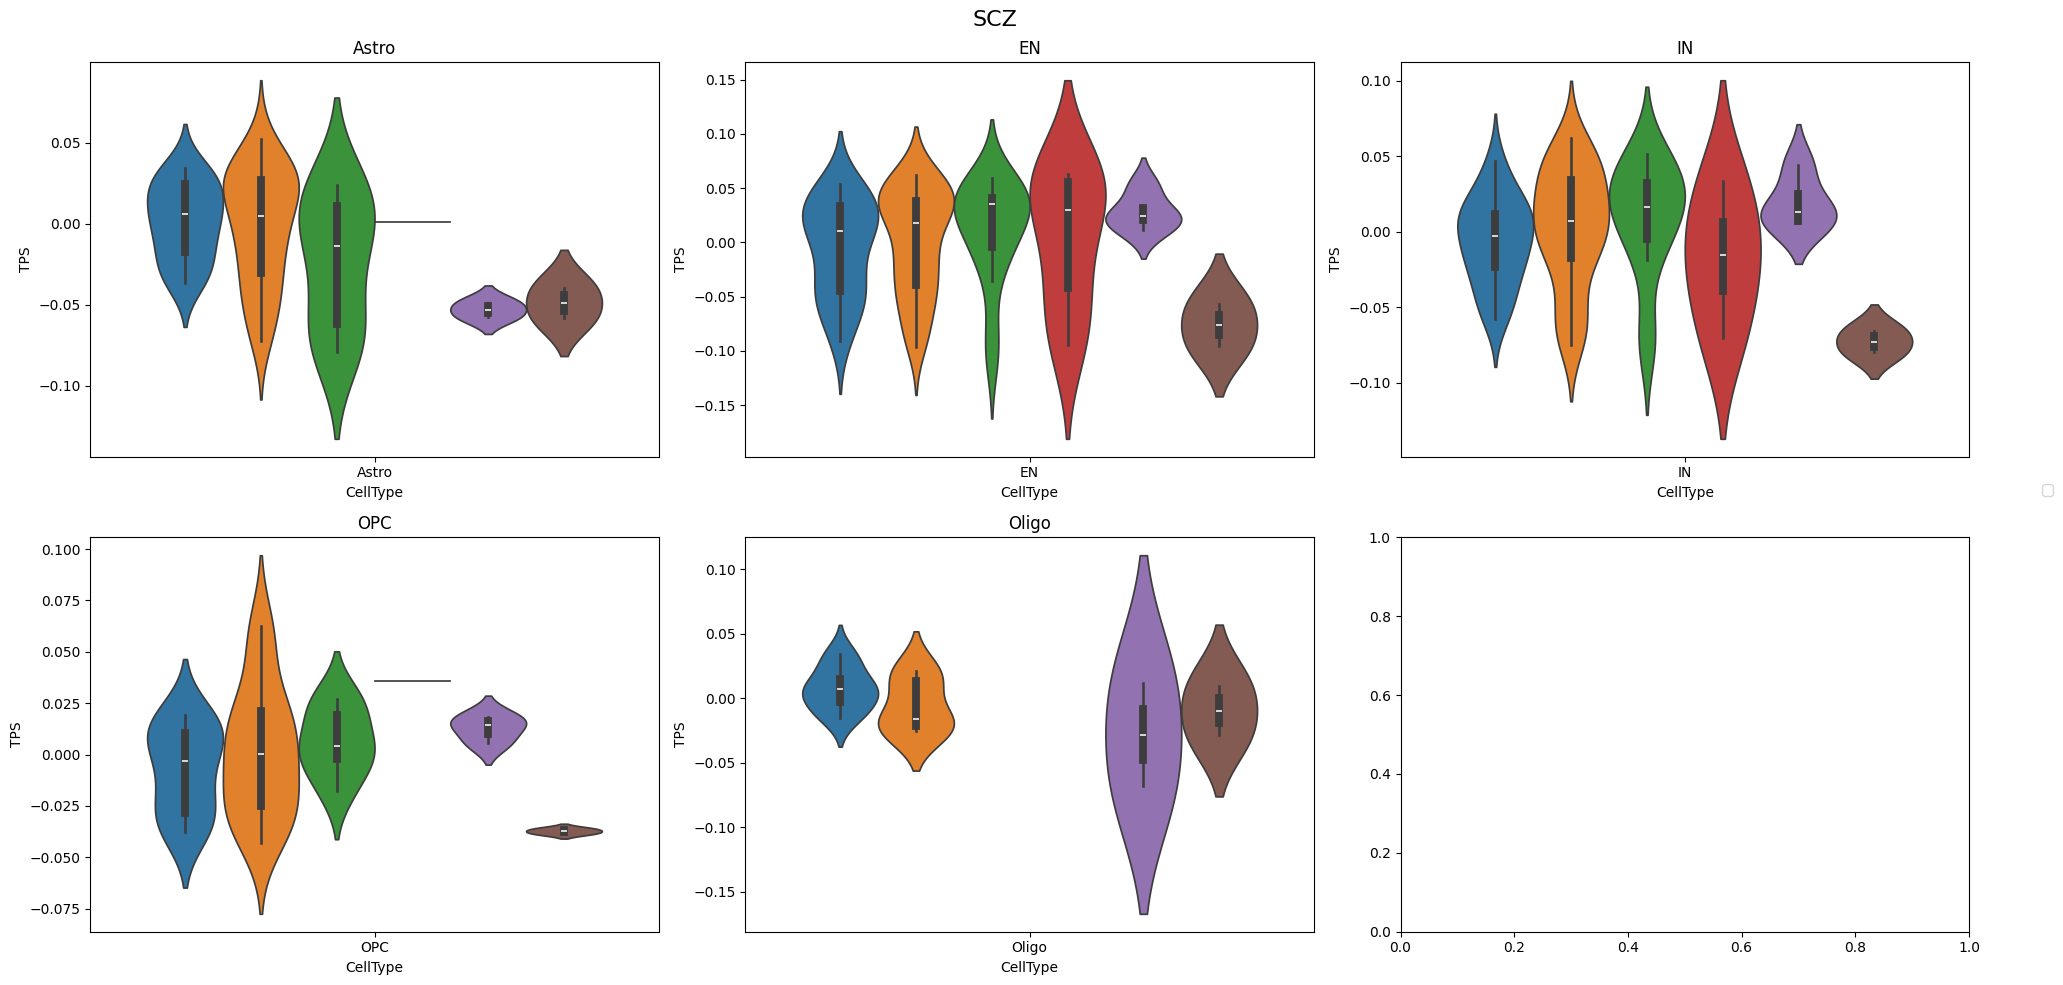

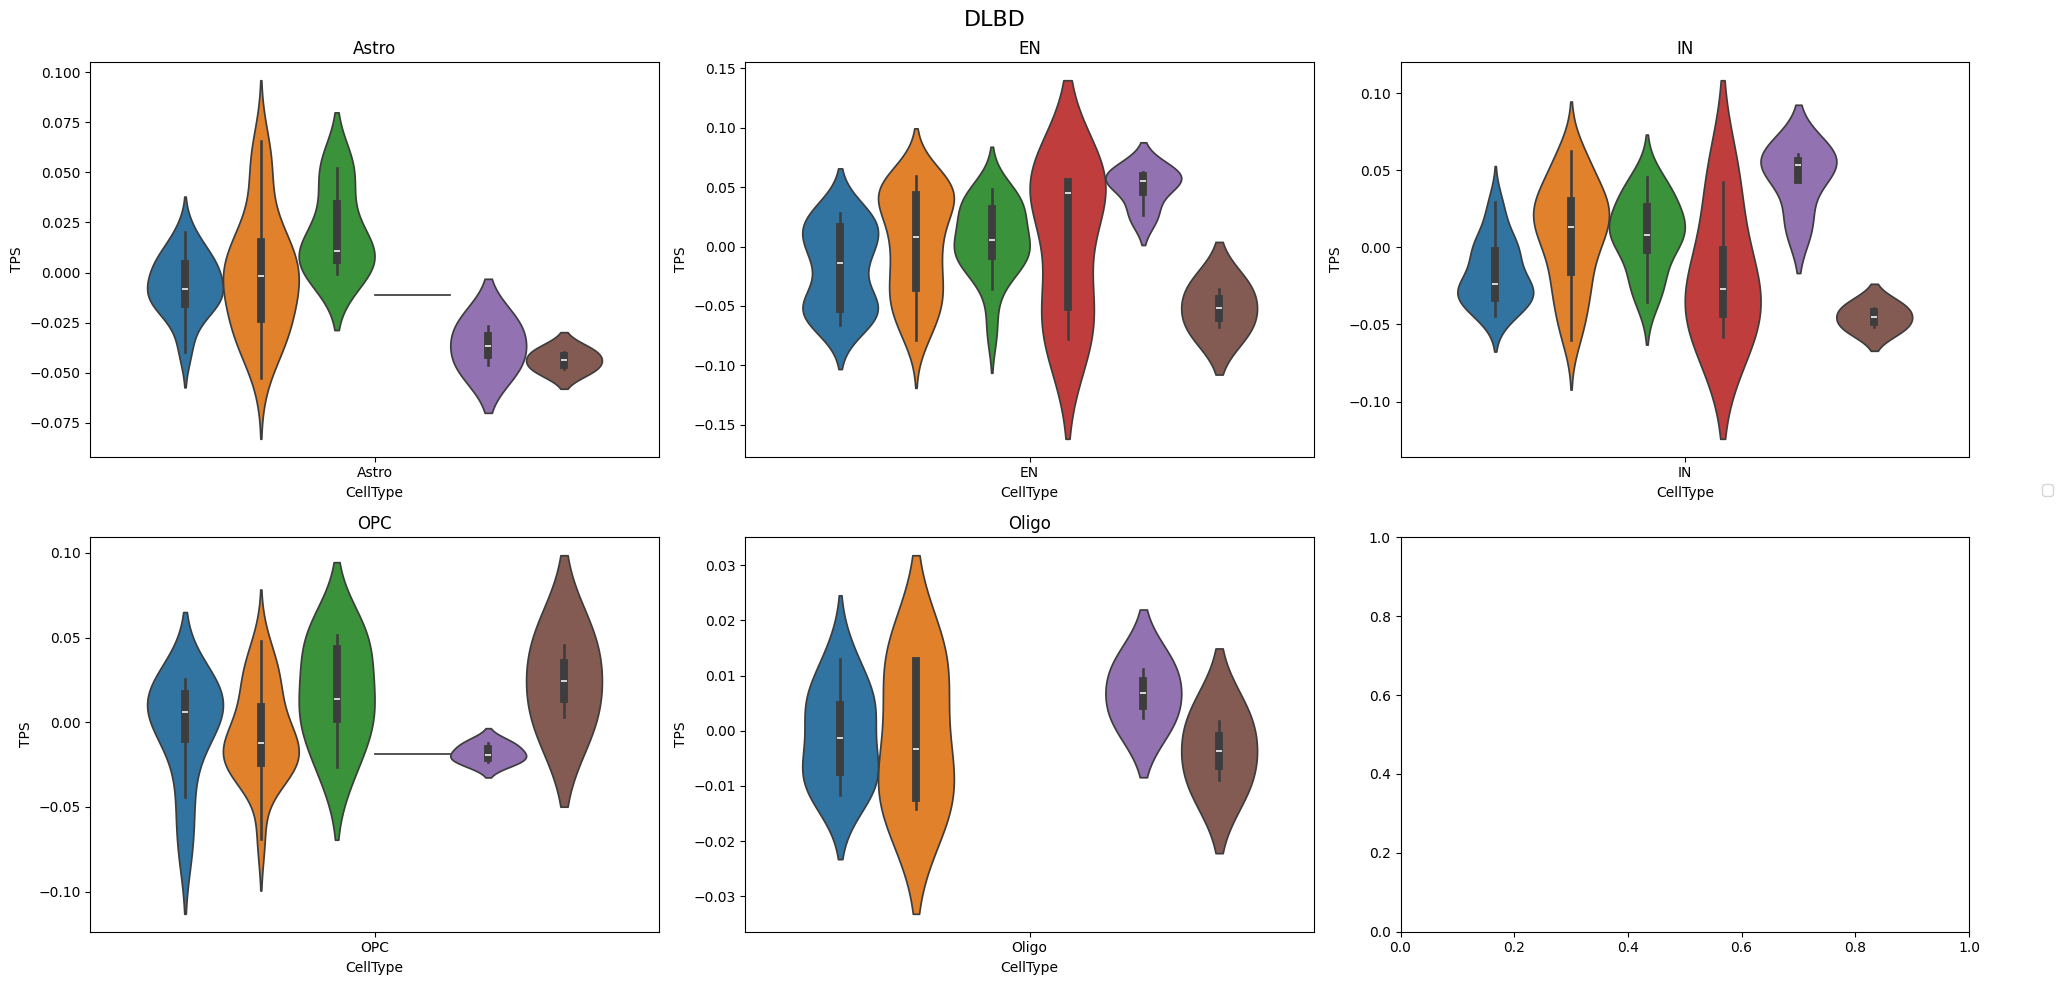

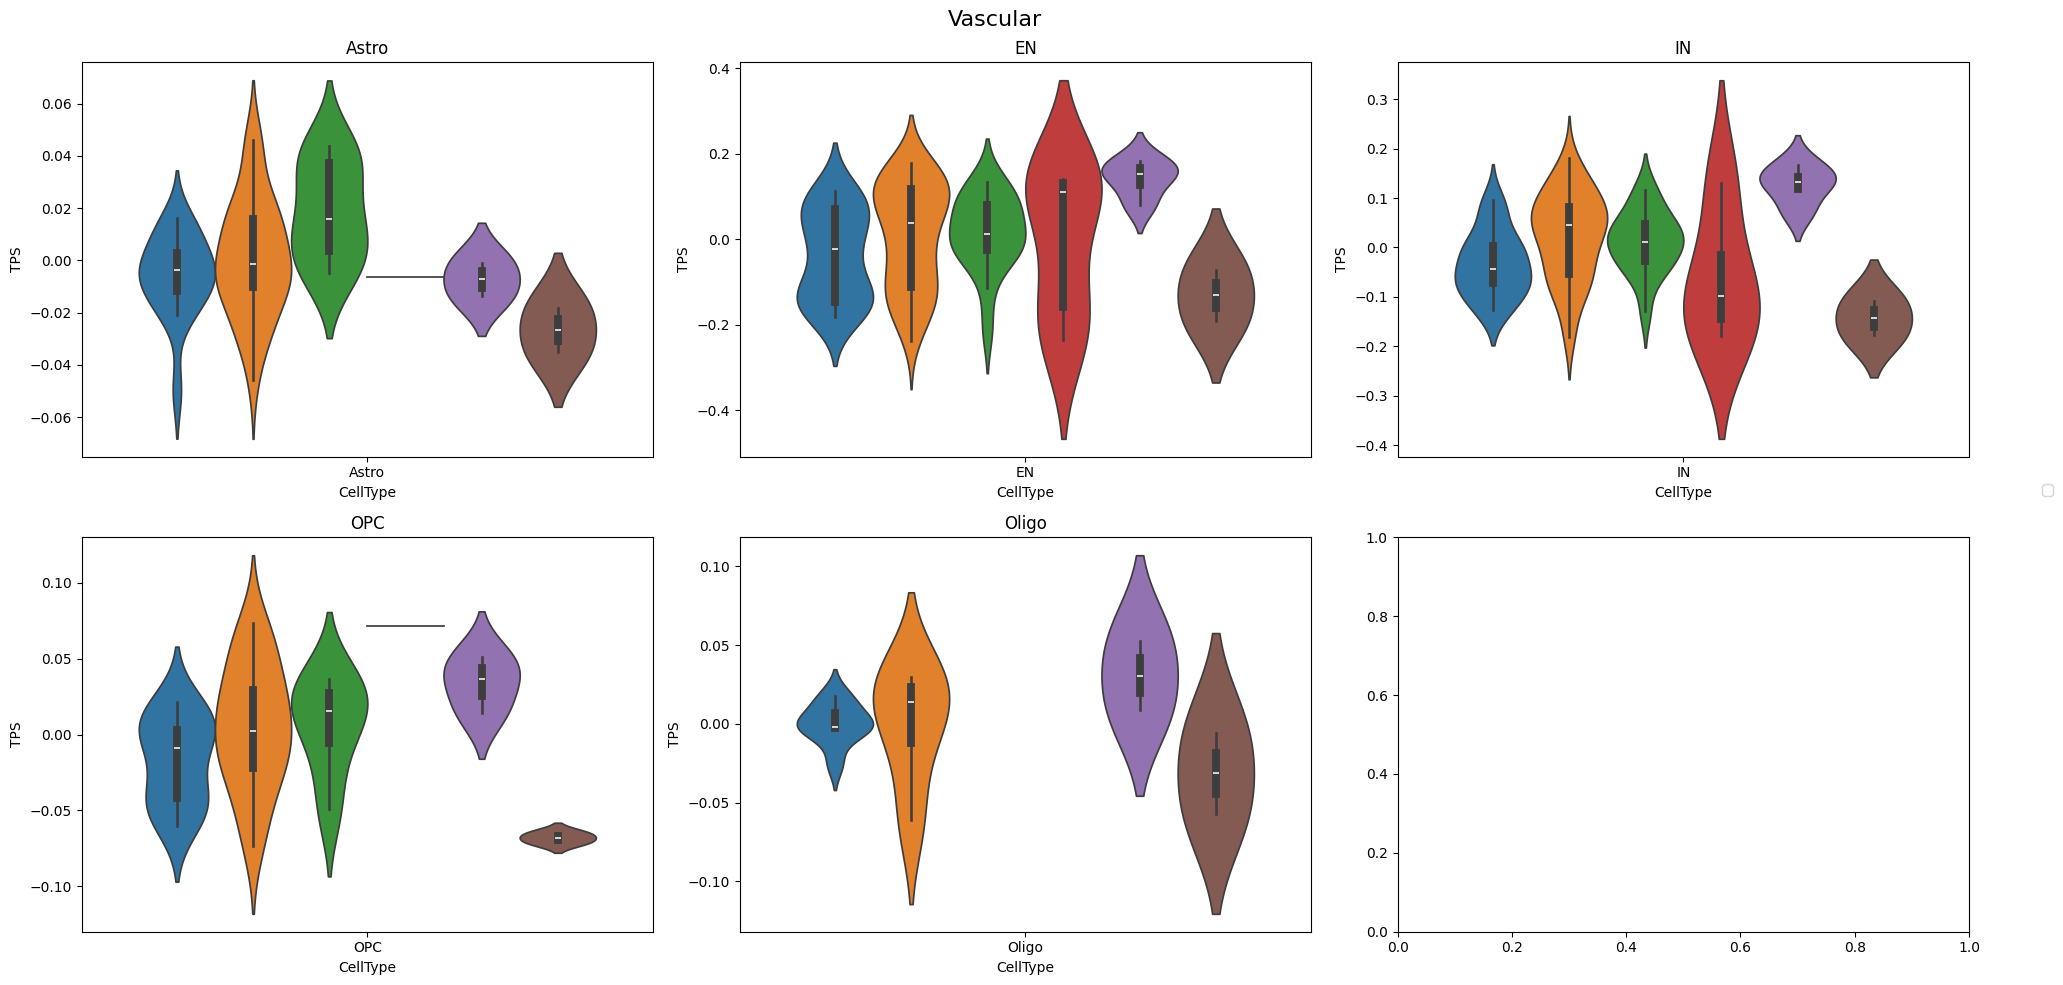

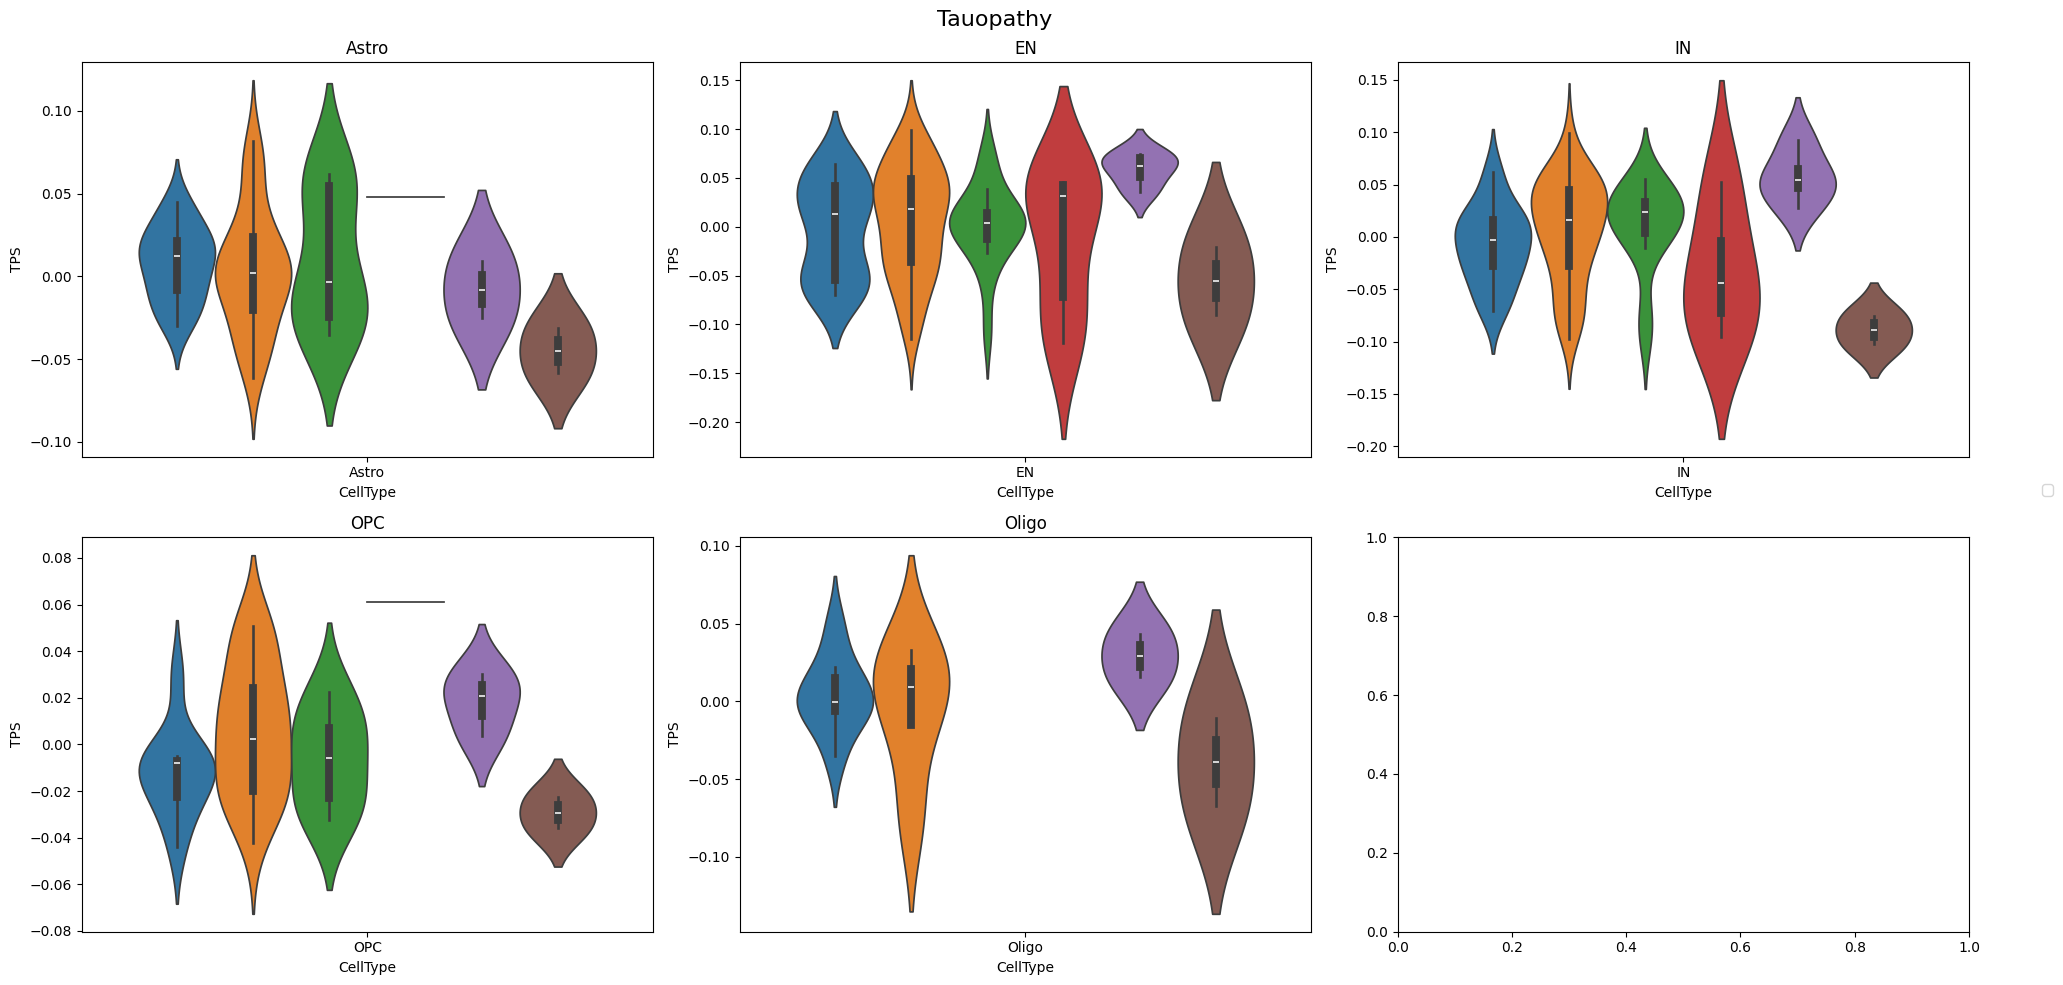

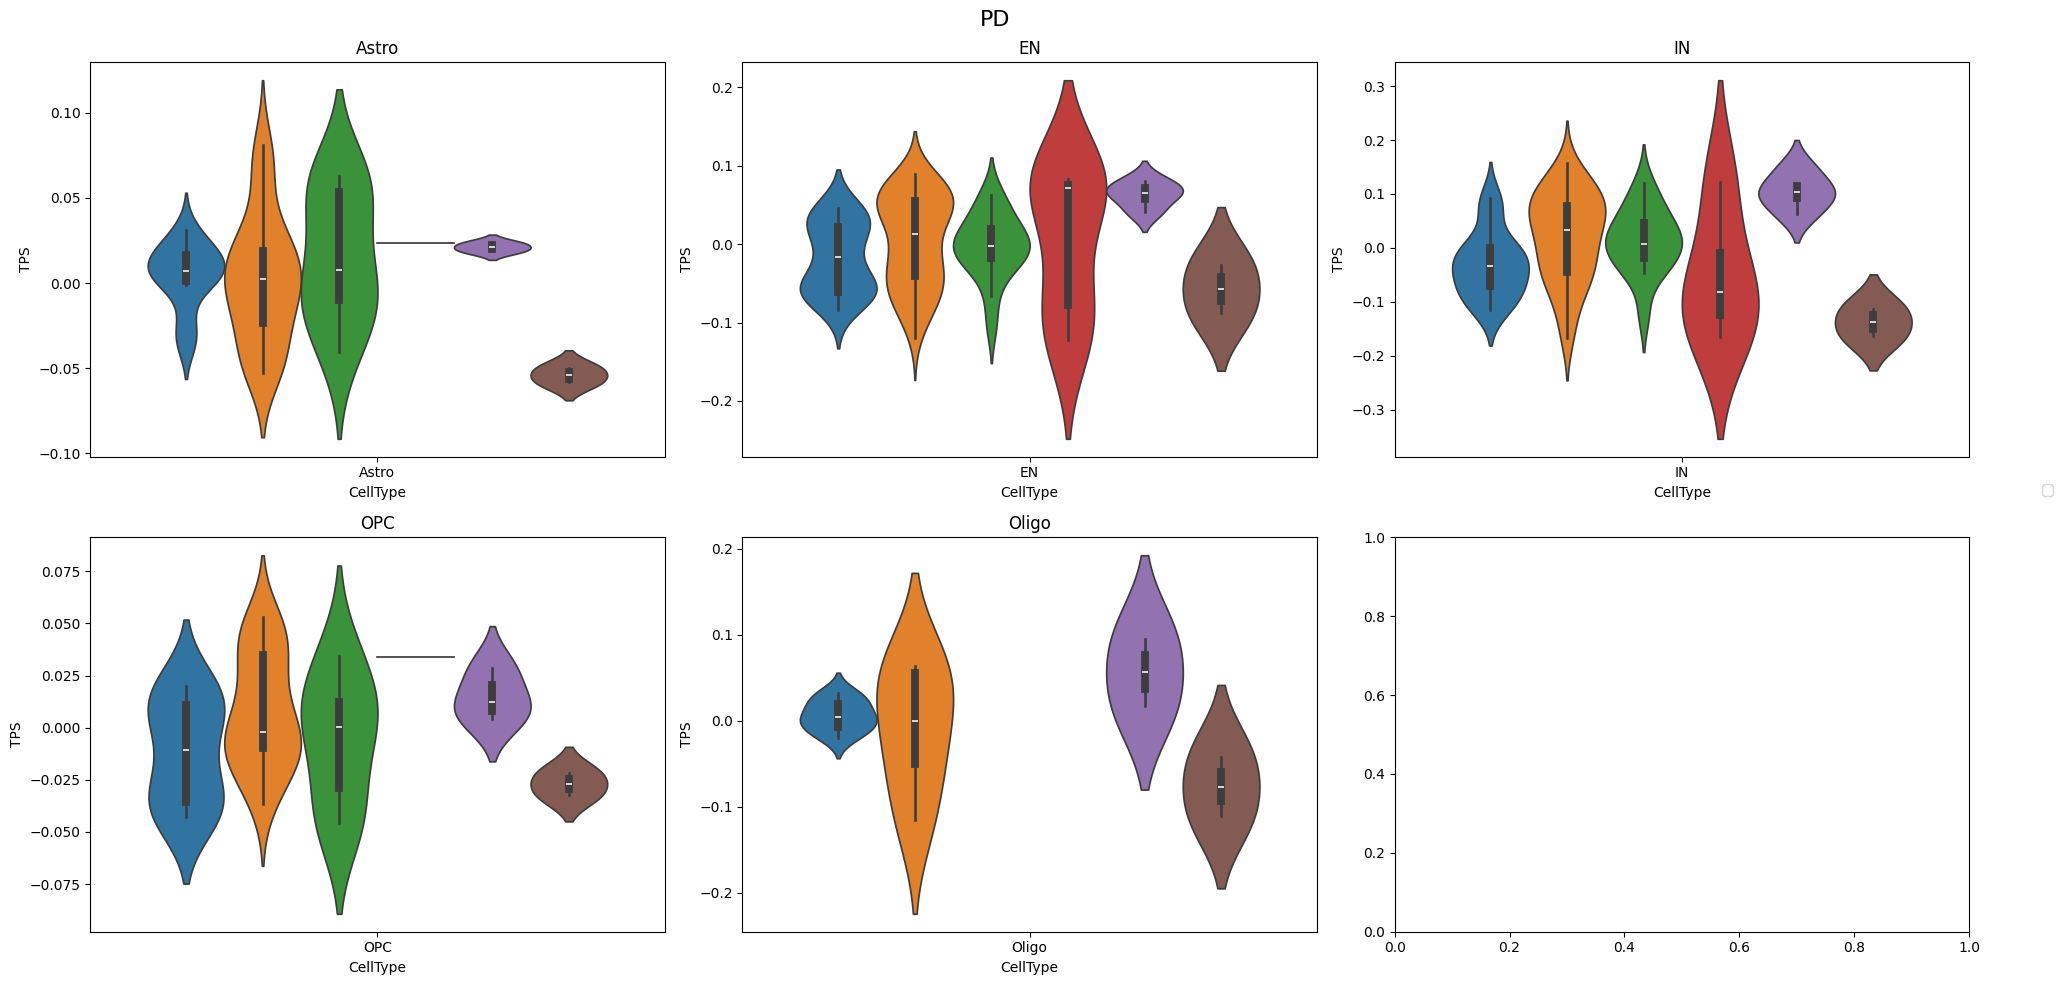

In [14]:
celltypes = tps_melted['CellType'].unique()
diseases = tps_melted['Disease'].unique()

for disease in diseases:
    fig, axes = plt.subplots(2, 3, figsize=(20, 10))
    axes = axes.flatten()
    
    for i, celltype in enumerate(celltypes):
        ax = axes[i]
        
        temp_tps = tps_melted[
            (tps_melted['CellType'] == celltype) &
            (tps_melted['Disease'] == disease)
        ]
    
        sns.violinplot(
            data=temp_tps,
            x='CellType',
            y='TPS',
            hue='Broad_Genotype',
            ax=ax,
            legend=False
        )
        
        ax.set_title(celltype)
    
    # single legend for the figure
    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(handles, labels, bbox_to_anchor=(1.02, 0.5), loc='center left')

    fig.suptitle(disease, fontsize=16)

    plt.tight_layout()
    plt.show()

In [18]:
## Write TPS To File ##

all_tps.to_csv('/mnt/sdb/scz_meta_analysis_processed/psychad_mapping/tps_files/all_tps.csv')

tps_melted.to_csv('/mnt/sdb/scz_meta_analysis_processed/psychad_mapping/tps_files/tps_melted.csv')

In [6]:
# ## Ruzicka...PsychENCODE, Science, 2023 ##

# ruzicka_string = "Ruzicka_PsychENCODE_Science_2023_NIHMS2109991-supplement-DataS4_DE_genes_merged_tables.xlsx"
# ruzicka_sheets = pd.read_excel('/mnt/sdb/scz_meta_analysis_processed/psychad_mapping/tps_files/' + ruzicka_string, sheet_name=None)